# Unitary Synthesis Workflow

This notebook demonstrates the Phase 2 `cqed_sim.unitary_synthesis` workflow:

- constraint-aware unitary synthesis
- leakage-aware noisy state mapping
- robust optimization under model uncertainty
- Pareto exploration, export, and warm starts


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim.core import (
    BosonicModeSpec,
    DispersiveCouplingSpec,
    FrameSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
)
from cqed_sim.pulses import Pulse, square_envelope
from cqed_sim.sim import NoiseSpec
from cqed_sim.unitary_synthesis import (
    CQEDSystemAdapter,
    LeakagePenalty,
    MultiObjective,
    Normal,
    ParameterDistribution,
    PrimitiveGate,
    SynthesisConstraints,
    Subspace,
    TargetStateMapping,
    TargetUnitary,
    UnitarySynthesizer,
)


## Define a Minimal cQED Model

We keep the Hilbert space small so the notebook stays fast while still exercising the real model-backed waveform path.


In [2]:
model = UniversalCQEDModel(
    transmon=TransmonModeSpec(
        omega=2.0 * np.pi * 6.0e9,
        dim=2,
        alpha=0.0,
        label='qubit',
        aliases=('qubit', 'transmon'),
        frame_channel='q',
    ),
    bosonic_modes=(
        BosonicModeSpec(
            label='storage',
            omega=2.0 * np.pi * 5.0e9,
            dim=2,
            kerr=2.0 * np.pi * (-2.0e3),
            aliases=('storage', 'cavity'),
            frame_channel='c',
        ),
    ),
    dispersive_couplings=(
        DispersiveCouplingSpec(mode='storage', chi=2.0 * np.pi * (-2.4e6)),
    ),
)
frame = FrameSpec(
    omega_c_frame=2.0 * np.pi * 5.0e9,
    omega_q_frame=2.0 * np.pi * 6.0e9,
)
system = CQEDSystemAdapter(model=model)
model.subsystem_dims


(2, 2)

## Workflow 1: Constraint-Aware Unitary Synthesis

Here the target is a closed-system unitary, and we add a simple duration constraint plus a multi-objective tradeoff on total time.


In [3]:
def rotation_y(theta: float) -> np.ndarray:
    return np.array(
        [
            [np.cos(theta / 2.0), -np.sin(theta / 2.0)],
            [np.sin(theta / 2.0), np.cos(theta / 2.0)],
        ],
        dtype=np.complex128,
    )

constraint_primitive = PrimitiveGate(
    name='ry',
    duration=60.0e-9,
    matrix=lambda params, model: rotation_y(float(params['theta'])),
    parameters={'theta': 0.2, 'duration': 60.0e-9},
    parameter_bounds={'theta': (-np.pi, np.pi), 'duration': (20.0e-9, 100.0e-9)},
    hilbert_dim=2,
)
constraint_target = TargetUnitary(rotation_y(np.pi / 2.0), ignore_global_phase=True)
constraint_synth = UnitarySynthesizer(
    primitives=[constraint_primitive],
    target=constraint_target,
    optimizer='powell',
    synthesis_constraints=SynthesisConstraints(max_duration=50.0e-9, duration_mode='hard'),
    objectives=MultiObjective(fidelity_weight=1.0, duration_weight=0.1),
    seed=7,
)
constraint_result = constraint_synth.fit(maxiter=40)
constraint_result.report['metrics']


{'fidelity': 0.999999999999976,
 'leakage_average': 0.0,
 'leakage_worst': 0.0,
 'leakage_selected': 0.0,
 'checkpoint_leakage_average': 0.0,
 'checkpoint_leakage_worst': 0.0,
 'state_error_mean': nan,
 'state_error_max': nan,
 'state_fidelity_mean': nan,
 'state_fidelity_min': nan,
 'reduced_state_fidelity_mean': nan,
 'reduced_state_fidelity_min': nan,
 'observable_error_mean': nan,
 'observable_error_max': nan,
 'weighted_observable_error': nan,
 'trajectory_task_loss': nan,
 'trajectory_state_error_mean': nan,
 'trajectory_observable_error_mean': nan,
 'channel_overlap': nan,
 'channel_choi_error': nan,
 'channel_superoperator_error': nan,
 'trace_preservation_error_mean': nan,
 'trace_preservation_error_max': nan,
 'trace_loss_mean': nan,
 'trace_loss_worst': nan,
 'choi_hermiticity_error': nan,
 'choi_min_eig': nan,
 'complete_positivity_violation': nan,
 'duration_metric': 0.8333333333333331,
 'gate_count_metric': 0.9171524053040581,
 'pulse_power_metric': 0.0,
 'amplitude_smoot

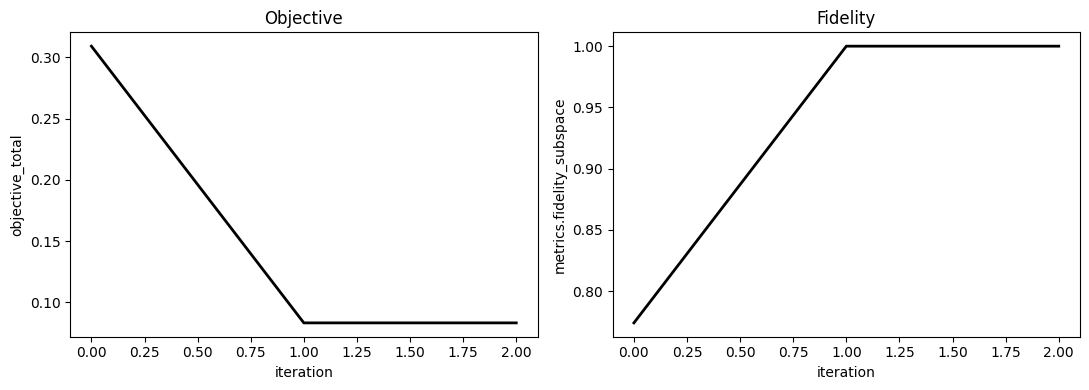

In [4]:
constraint_fig = constraint_result.plot_convergence()
plt.show()


## Workflow 2: Leakage-Aware Open-System State Mapping

The primitive is a real waveform, the target is a state mapping, and the optimization includes a leakage penalty and Lindblad noise.


In [5]:
def square_qubit_waveform(params, model):
    pulse = Pulse(
        'qubit',
        0.0,
        float(params['duration']),
        square_envelope,
        amp=float(params['amp']),
        phase=float(params['phase']),
        label='square_qubit_drive',
    )
    return [pulse], {'qubit': 'qubit'}

waveform_primitive = PrimitiveGate(
    name='square_drive',
    duration=40.0e-9,
    waveform=square_qubit_waveform,
    parameters={'amp': 5.0e6, 'phase': 0.0, 'duration': 40.0e-9},
    parameter_bounds={
        'amp': (-5.0e7, 5.0e7),
        'phase': (-np.pi, np.pi),
        'duration': (20.0e-9, 80.0e-9),
    },
    hilbert_dim=4,
)

full_space = Subspace.custom(4, range(4), labels=('|g,0>', '|g,1>', '|e,0>', '|e,1>'))
psi0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.complex128)
phi0 = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.complex128)

state_synth = UnitarySynthesizer(
    subspace=full_space,
    system=system,
    backend='pulse',
    primitives=[waveform_primitive],
    target=TargetStateMapping(initial_state=psi0, target_state=phi0),
    leakage_penalty=LeakagePenalty(weight=0.2),
    objectives=MultiObjective(fidelity_weight=1.0, leakage_weight=0.2, pulse_power_weight=0.05),
    optimizer='differential_evolution',
    optimize_times=False,
    simulation_options={'frame': frame, 'dt': 2.0e-9, 'noise': NoiseSpec(t1=40.0e-6, tphi=30.0e-6)},
    seed=5,
)
state_result = state_synth.fit(maxiter=4)
state_result.report['metrics']


{'fidelity': 0.9995600290160418,
 'leakage_average': 0.0,
 'leakage_worst': 0.0,
 'leakage_selected': 0.0,
 'checkpoint_leakage_average': 0.0,
 'checkpoint_leakage_worst': 0.0,
 'state_error_mean': 0.00022334361248654903,
 'state_error_max': 0.00022334361248654903,
 'state_fidelity_mean': 0.9995600290160418,
 'state_fidelity_min': 0.9995600290160418,
 'reduced_state_fidelity_mean': nan,
 'reduced_state_fidelity_min': nan,
 'observable_error_mean': nan,
 'observable_error_max': nan,
 'weighted_observable_error': nan,
 'trajectory_task_loss': nan,
 'trajectory_state_error_mean': nan,
 'trajectory_observable_error_mean': nan,
 'channel_overlap': nan,
 'channel_choi_error': nan,
 'channel_superoperator_error': nan,
 'trace_preservation_error_mean': nan,
 'trace_preservation_error_max': nan,
 'trace_loss_mean': nan,
 'trace_loss_worst': nan,
 'choi_hermiticity_error': nan,
 'choi_min_eig': nan,
 'complete_positivity_violation': nan,
 'duration_metric': 40.0,
 'gate_count_metric': 1.0,
 'pul

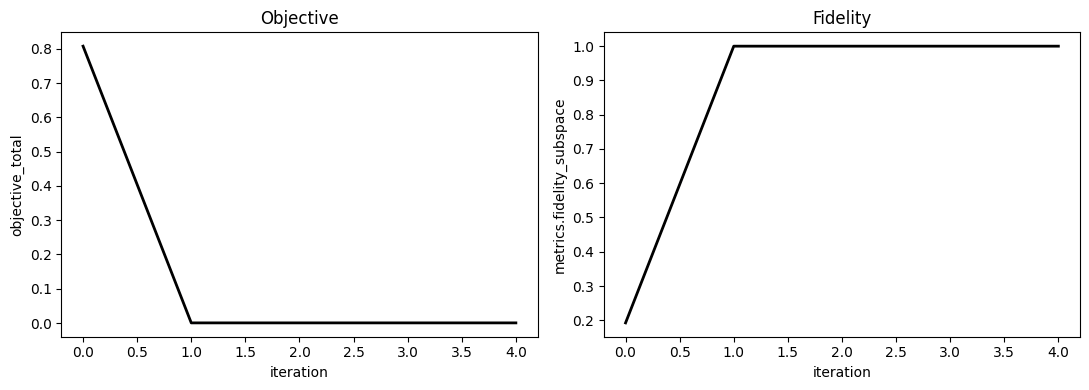

In [6]:
state_fig = state_result.plot_convergence(fidelity_what='metrics.fidelity_subspace')
plt.show()


## Workflow 3: Robust Optimization Under Parameter Uncertainty

Now we reuse the same waveform primitive, but we optimize against a distribution of uncertain `chi` values instead of a single nominal model.


In [7]:
robust_synth = UnitarySynthesizer(
    subspace=full_space,
    system=system,
    backend='pulse',
    primitives=[waveform_primitive],
    target=TargetStateMapping(initial_state=psi0, target_state=phi0),
    leakage_penalty=LeakagePenalty(weight=0.2),
    objectives=MultiObjective(fidelity_weight=1.0, leakage_weight=0.2, robustness_weight=1.0),
    parameter_distribution=ParameterDistribution(
        sample_count=2,
        aggregate='mean',
        chi=Normal(2.0 * np.pi * (-2.4e6), 2.0 * np.pi * 0.05e6),
    ),
    optimizer='powell',
    optimize_times=False,
    simulation_options={'frame': frame, 'dt': 2.0e-9, 'noise': NoiseSpec(t1=40.0e-6, tphi=30.0e-6)},
    seed=11,
)
robust_result = robust_synth.fit(maxiter=2)
robust_result.report['robustness']


{'enabled': True,
 'aggregate': 'mean',
 'samples': [{'assignment': {'chi': -15079644.737231007},
   'objective': 1.2905196283059077e-06,
   'fidelity': 0.999616208224443,
   'fidelity_loss': 0.0003837917755570297,
   'leakage_average': 0.0,
   'leakage_worst': 0.0},
  {'assignment': {'chi': -15891129.067342954},
   'objective': 1.2905196283059077e-06,
   'fidelity': 0.999616208224443,
   'fidelity_loss': 0.0003837917755570297,
   'leakage_average': 0.0,
   'leakage_worst': 0.0},
  {'assignment': {'chi': -15054122.954506261},
   'objective': 1.2905196283059077e-06,
   'fidelity': 0.999616208224443,
   'fidelity_loss': 0.0003837917755570297,
   'leakage_average': 0.0,
   'leakage_worst': 0.0}],
 'objective': 1.2905196283059077e-06,
 'penalty': 0.0}

## Workflow 4: Export, Warm Start, and Pareto Exploration


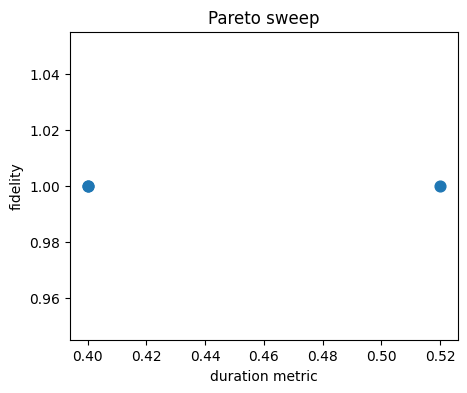

Warm-start fidelity: 1.0
Pareto nondominated indices: [1, 2]


In [8]:
export_path = Path('tutorials/30_advanced_protocols/_phase2_unitary_synthesis_solution.json')
constraint_result.save(export_path)

warm_start_synth = UnitarySynthesizer(
    primitives=[PrimitiveGate(
        name='ry',
        duration=60.0e-9,
        matrix=lambda params, model: rotation_y(float(params['theta'])),
        parameters={'theta': 0.2, 'duration': 60.0e-9},
        parameter_bounds={'theta': (-np.pi, np.pi), 'duration': (20.0e-9, 100.0e-9)},
        hilbert_dim=2,
    )],
    target=constraint_target,
    optimizer='powell',
    warm_start=export_path,
    seed=7,
)
warm_start_result = warm_start_synth.fit(maxiter=1)

pareto_front = constraint_synth.explore_pareto(
    [
        MultiObjective(fidelity_weight=1.0, duration_weight=0.0),
        MultiObjective(fidelity_weight=1.0, duration_weight=0.2),
        MultiObjective(fidelity_weight=1.0, duration_weight=0.5),
    ],
    maxiter=6,
)

pareto_points = [
    (
        result.report['metrics']['duration_metric'],
        result.report['metrics']['fidelity'],
    )
    for result in pareto_front.results
]

plt.figure(figsize=(5, 4))
plt.scatter([point[0] for point in pareto_points], [point[1] for point in pareto_points], s=60)
plt.xlabel('duration metric')
plt.ylabel('fidelity')
plt.title('Pareto sweep')
plt.show()

print('Warm-start fidelity:', warm_start_result.report['metrics']['fidelity'])
print('Pareto nondominated indices:', pareto_front.nondominated_indices)

export_path.unlink(missing_ok=True)


## Interpretation

The same synthesis engine can now switch between:

- closed-system unitary optimization with explicit constraints
- noisy/leakage-aware state mapping
- robust optimization over uncertain Hamiltonian parameters
- iterative workflows built around saved results and Pareto sweeps

That is the intended Phase 2 usage pattern for realistic bosonic/cQED control studies.


## Workflow 5: Channel-First Targets and Isometry Metrics

This section demonstrates the generalized target layer added on top of the original unitary/state-transfer workflows:

- coherent isometry scoring on a restricted logical input subspace
- explicit metric selection, where the same target can be optimized with either coherent or basis-transfer fidelity
- channel-style diagnostics for full process matching

The code below is self-contained, so it can be run without executing the earlier cells in this notebook.

In [ ]:
from cqed_sim.unitary_synthesis import ExecutionOptions, TargetChannel, TargetIsometry


def workflow5_rotation_y(theta: float) -> np.ndarray:
    return np.array(
        [
            [np.cos(theta / 2.0), -np.sin(theta / 2.0)],
            [np.sin(theta / 2.0), np.cos(theta / 2.0)],
        ],
        dtype=np.complex128,
    )


def workflow5_hadamard() -> np.ndarray:
    return np.array([[1.0, 1.0], [1.0, -1.0]], dtype=np.complex128) / np.sqrt(2.0)


def workflow5_cnot() -> np.ndarray:
    return np.array(
        [
            [1.0, 0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 1.0],
            [0.0, 0.0, 1.0, 0.0],
        ],
        dtype=np.complex128,
    )


encoder = workflow5_cnot() @ np.kron(workflow5_hadamard(), np.eye(2, dtype=np.complex128))
perfect_isometry = UnitarySynthesizer(
    subspace=Subspace.custom(4, range(4)),
    primitives=[PrimitiveGate(name='encoder', duration=30.0e-9, matrix=encoder, hilbert_dim=4)],
    target=TargetIsometry(encoder[:, :2]),
    optimize_times=False,
    seed=19,
).fit(maxiter=1)

phase_skew = np.diag([1.0, -1.0, 1.0, 1.0]).astype(np.complex128)
coherent_metric = UnitarySynthesizer(
    subspace=Subspace.custom(4, range(4)),
    primitives=[PrimitiveGate(name='phase_skew', duration=20.0e-9, matrix=phase_skew, hilbert_dim=4)],
    target=TargetIsometry(np.eye(4, dtype=np.complex128)[:, :2]),
    optimize_times=False,
    seed=23,
).fit(maxiter=1)

basis_metric = UnitarySynthesizer(
    subspace=Subspace.custom(4, range(4)),
    primitives=[PrimitiveGate(name='phase_skew', duration=20.0e-9, matrix=phase_skew, hilbert_dim=4)],
    target=TargetIsometry(np.eye(4, dtype=np.complex128)[:, :2]),
    metric='isometry_basis_fidelity',
    optimize_times=False,
    seed=23,
).fit(maxiter=1)

explicit_input = UnitarySynthesizer(
    subspace=Subspace.custom(4, range(4)),
    primitives=[PrimitiveGate(name='identity4', duration=20.0e-9, matrix=np.eye(4, dtype=np.complex128), hilbert_dim=4)],
    target=TargetIsometry.from_basis_map(
        target_states=[
            np.array([1.0, 0.0, 0.0, 0.0], dtype=np.complex128),
            np.array([0.0, 0.0, 1.0, 0.0], dtype=np.complex128),
        ],
        input_subspace=Subspace.custom(4, [0, 2]),
    ),
    optimize_times=False,
    seed=29,
).fit(maxiter=1)

channel_result = UnitarySynthesizer(
    subspace=Subspace.custom(2, range(2)),
    primitives=[
        PrimitiveGate(
            name='ry',
            duration=20.0e-9,
            matrix=lambda params, model: workflow5_rotation_y(float(params['theta'])),
            parameters={'theta': 0.1, 'duration': 20.0e-9},
            parameter_bounds={'theta': (-2.0 * np.pi, 2.0 * np.pi), 'duration': (10.0e-9, 30.0e-9)},
            hilbert_dim=2,
        )
    ],
    target=TargetChannel(unitary=workflow5_rotation_y(np.pi / 2.0), enforce_cptp=True),
    optimizer='powell',
    execution=ExecutionOptions(engine='numpy'),
    optimize_times=False,
    seed=31,
).fit(maxiter=40)

workflow5_summary = {
    'perfect_isometry_coherent_fidelity': perfect_isometry.report['metrics']['isometry_coherent_fidelity'],
    'perfect_isometry_basis_fidelity': perfect_isometry.report['metrics']['isometry_basis_fidelity'],
    'phase_skew_default_metric': coherent_metric.report['objective']['selected_metrics']['selected_metric_name'],
    'phase_skew_default_objective': coherent_metric.objective,
    'phase_skew_basis_metric': basis_metric.report['objective']['selected_metrics']['selected_metric_name'],
    'phase_skew_basis_objective': basis_metric.objective,
    'explicit_input_isometry_coherent_fidelity': explicit_input.report['metrics']['isometry_coherent_fidelity'],
    'channel_process_fidelity': channel_result.report['metrics']['channel_process_fidelity'],
    'channel_choi_error': channel_result.report['metrics']['channel_choi_error'],
}
workflow5_summary

The summary dictionary above should show three behaviors that the older workflow could not express cleanly:

- the exact encoder has both coherent and basis-transfer isometry fidelity near 1
- the `phase_skew` example gives a large coherent-metric cost but zero basis-transfer cost, because only the relative logical-column phase changed
- the explicit-input-subspace example treats the logical domain as `|0⟩` and `|2⟩`, not just the leading basis vectors

That is the intended workflow when the task is an encoding map or restricted-domain channel rather than a square logical unitary.

## Workflow 6: Leakage-Aware Relevant-Map Optimization and Visualization

This workflow uses the same helper script as `examples/unitary_synthesis_leakage_aware_visualization.py`.

The task is intentionally defined on a reduced target action: it only cares about the logical qubit after tracing out an ancillary leakage register. That creates a family of equally valid relevant-map matches, and the leakage penalties then decide which member of that family is preferred.

The three cases below compare:

- no leakage penalty
- logical-subspace leakage penalty
- logical leakage plus an edge-projector penalty that pushes residual leakage away from the highest ancillary level

This is the intended pattern when the task should optimize only the relevant map, but still report and suppress where the discarded amplitude goes.

In [ ]:
import matplotlib.pyplot as plt

from examples.unitary_synthesis_leakage_aware_visualization import (
    comparison_summary,
    plot_case_overview,
    run_comparison,
)

workflow6_results = run_comparison(maxiter_penalized=8)
workflow6_summary = comparison_summary(workflow6_results)
workflow6_summary

In [ ]:
workflow6_figures = plot_case_overview(workflow6_results)
plt.show()

The summary and figures should show the intended relevant-map behavior:

- all three runs keep the reduced logical action at fidelity 1 because the task ignores the ancillary leakage register
- the no-penalty run keeps a large ancilla excursion because that hidden motion is invisible to the task metric
- the leakage penalty drives the ancilla excursion down to its structural floor
- the added edge penalty keeps the same total residual leakage floor but redirects it away from the highest ancillary level

This is the key distinction from full-space unitary matching: the optimizer is still solving only the reduced task, and leakage-aware terms are layered on top as explicit regularizers and diagnostics.